# <h1 style="color: yellow;">Decision Tree Regression Model (first alternative model)</h1>

## Libraries

In [18]:
#Call libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

## Training and tests variables import

In [19]:
#Import 80/20 model
import sys
sys.path.append("../")

from Variables.Training_test_variables_80_20 import (
    X,
    y,
    X_train,
    X_test,
    y_train,
    y_test
)

## One-Hot encoding

In [20]:
#Columns type identification
categorical_columns = X.select_dtypes(
    include=["object", "string"]
).columns.tolist() #-> 14

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist() #-> 6

#Create the categorical columns preprocessing (the combination of values will result in 34 new categorical columns)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        )
    ],
    remainder="passthrough" #The numeric columns will pass directly
)
#Note:
#The `handle_unknown="ignore"` setting is important. Imagine a category appearing in `X_test` that didn't exist in `X_train`. The encoder won't break.

## Create the pipeline with tree regression (model overview)

In [21]:
#Model tree (considering the preprocessor)
model_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(random_state=42))
])
#For other definitions 42 is "life, the universe, and everything else

In [22]:
#Model training (fit)
model_tree.fit(X_train, y_train)
#Use X_train as the input variables and x_train as the correct values ​​to learn the relationship between them.

#Model prediction
y_pred = model_tree.predict(X_test)
#X_test must remain separate to evaluate whether the model can generalize to data it did not use for learning.

In [23]:
#Tree regression model overview
display(model_tree)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatica

## Using loss functions to validate the model (metrics comparison)

In [24]:
#Mean absolute error
mae = mean_absolute_error(y_test, y_pred)

#Mean squared error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

#r2 error
r2 = r2_score(y_test, y_pred)

#r2 error adjusted
n = len(y_test)
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

#Results from model
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")
print(f"Adjusted R²: {adjusted_r2:.3f}")

MAE:  1.83
RMSE: 3.54
R²:   0.199
Adjusted R²: 0.187


In [25]:
#Decision Tree Model evaluation notes:

#MAE = 1.83
#Good average prediction accuracy. Baseline is better.

#RMSE = 3.54
#Attention: the difference from MAE suggests the presence
#of some predictions with considerably larger errors.

#R² = 0.199
#The model explains approximately 19.9% of the variance in Exam_Score.
#For this dataset, the baseline Linear Regression significantly outperformed the Decision Tree in the current configuration.

#Adjusted R² = 0.187
#Not good

In [26]:
#It is necessary to apply a hyperparameter tuning in this model to evaluate it. 
#Given that the adjusted R² is lower than the R² of the baseline model. 

## Tuned Decision Tree (Hyperparameter Tuning)

### Using GridSearchCV

In [27]:
#Here, we are moving from “training a tree” to “searching for a better configuration for the tree.”
#1. receives various hyperparameter possibilities;
#2. creates different combinations;
#3. trains the tree for each combination;
#4. uses cross-validation to evaluate each combination;
#5. identifies the configuration that performed best according to the chosen metric.

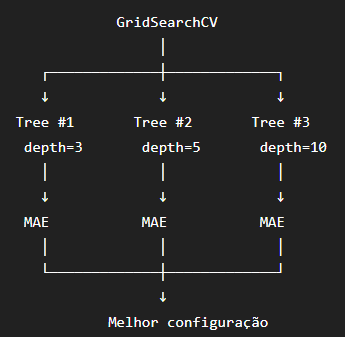

In [28]:
#Definition of parameters for the combinations
#We are using regresser because is a pipeline tree
param_grid = {
    "regressor__max_depth": [3, 5, 7, 10, 15, None],
    "regressor__min_samples_split": [2, 5, 10, 15, 20],
    "regressor__min_samples_leaf": [1, 2, 5, 10, 15, 20]
}
#max_depth → maximum depth of the tree.
#3   → simple tree
#5   → relatively simple
#7   → intermediate
#10  → more complex
#15  → quite complex
#None → no explicit limit
#min_samples_split → minimum number of observations required to split a node.
#min_samples_leaf → minimum number of observations a leaf can have.

In [29]:
#Create GridSearchCV
grid_search_tree = GridSearchCV(
    estimator=model_tree,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)
#Note:
#cv=5
    #It stands for 5-fold cross-validation.
    #The training data will be split into 5 parts, and the model will be trained and tested multiple times to find a more robust configuration.
#scoring="neg_mean_absolute_error"
    #It means we are choosing the hyperparameters by aiming for the lowest MAE.


In [30]:
#GridSearch training
grid_search_tree.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__max_depth': [3, 5, ...], 'regressor__min_samples_leaf': [1, 2, ...], 'regressor__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callab

### Make predictions using the best tree

In [31]:
#Discovery of the best parameters and best score MAE
print(grid_search_tree.best_params_)
print(grid_search_tree.best_score_)
#Note:
#The best_score_ will be negative because we are using neg_mean_absolute_error.
#scikit-learn uses `neg_mean_absolute_error` because `GridSearchCV` assumes that higher metric values ​​are better. 
#That is why the MAE appears with a negative sign internally.
print(f"Best CV MAE: {-grid_search_tree.best_score_:.4f}")

{'regressor__max_depth': 15, 'regressor__min_samples_leaf': 15, 'regressor__min_samples_split': 2}
-1.5733491453695099
Best CV MAE: 1.5733


In [32]:
#GridSearchCV itself stores the best model
best_tree = grid_search_tree.best_estimator_
y_pred_tree_tuned = best_tree.predict(X_test)

### Using loss functions to validate the new model (metrics comparison)

In [33]:
mae_tree_tuned = mean_absolute_error(
    y_test,
    y_pred_tree_tuned
)

rmse_tree_tuned = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tree_tuned
    )
)

r2_tree_tuned = r2_score(
    y_test,
    y_pred_tree_tuned
)

print(f"MAE:  {mae_tree_tuned:.2f}")
print(f"RMSE: {rmse_tree_tuned:.2f}")
print(f"R²:   {r2_tree_tuned:.3f}")

MAE:  1.55
RMSE: 2.69
R²:   0.539


In [ ]:
#Decision Tree Hyperparameter Tuning: The default Decision Tree showed poor generalization performance. 
#After applying GridSearchCV with 5-fold cross-validation to optimize max_depth, min_samples_split, and min_samples_leaf, the model improved substantially, reducing MAE from 1.83 to 1.55, reducing RMSE from 3.54 to 2.69, and increasing R² from 0.199 to 0.539. 
#Despite this improvement, the tuned Decision Tree still underperformed the Linear Regression baseline (MAE = 0.48, RMSE = 2.04, R² = 0.734), indicating that the linear model remained the strongest performer at this stage.

## Model Performance Comparison

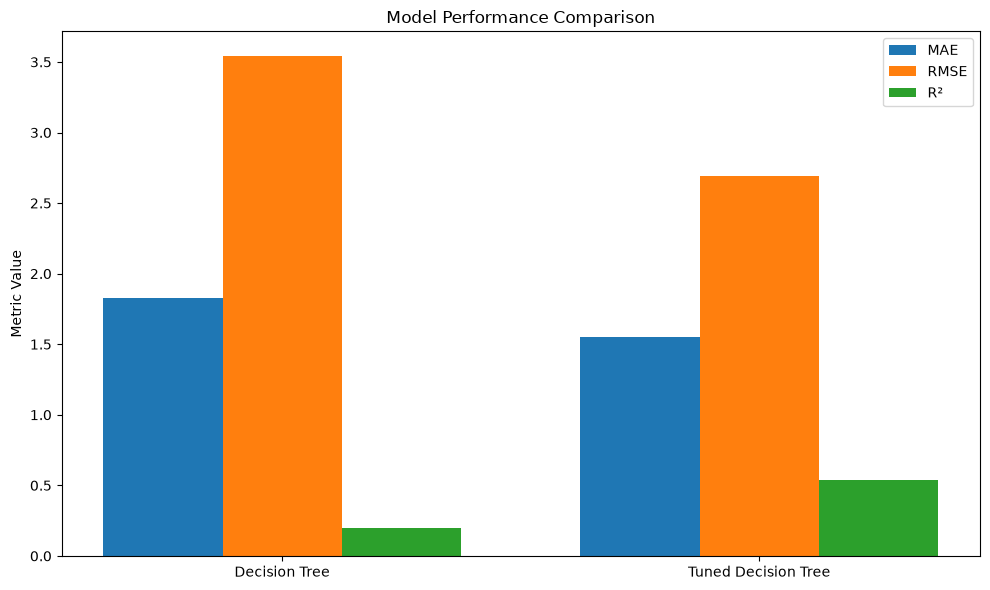

In [ ]:
#Graph definition
models = [
    "Decision Tree",
    "Tuned Decision Tree"
]

mae_values = [1.83, 1.55]
rmse_values = [3.54, 2.69]
r2_values = [0.199, 0.539]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(x - width, mae_values, width, label="MAE")
plt.bar(x, rmse_values, width, label="RMSE")
plt.bar(x + width, r2_values, width, label="R²")

plt.xticks(x, models)
plt.ylabel("Metric Value")
plt.title("Model Performance Comparison")
plt.legend()

plt.tight_layout()
plt.show()